In [1]:
# Install dependencies
!pip install -q transformers datasets torch yake nltk scikit-learn matplotlib seaborn

In [ ]:
# Imports
import torch
import pandas as pd
import numpy as np
import yake
import nltk
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from nltk.corpus import stopwords
from datasets import Dataset
from sklearn.preprocessing import LabelEncoder
from transformers import (
    AutoTokenizer,
    AutoModelForCausalLM,
    TrainingArguments,
    Trainer,
    DataCollatorForLanguageModeling
)

# Download NLTK data
nltk.download('stopwords', quiet=True)
nltk.download('punkt', quiet=True)

# Device setup
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

Using device: cuda


In [3]:
# Constants
ID2LABEL = {
    0: "Angry", 1: "Anticipation", 2: "Disgust", 3: "Fear",
    4: "Happy", 5: "Neutral", 6: "Sad", 7: "Surprise", 8: "Trust"
}
LABEL_NAMES = list(ID2LABEL.values())

print("Label mappings:")
for idx, label in ID2LABEL.items():
    print(f"  {idx}: {label}")

Label mappings:
  0: Angry
  1: Anticipation
  2: Disgust
  3: Fear
  4: Happy
  5: Neutral
  6: Sad
  7: Surprise
  8: Trust


2. Helper functions


In [4]:
def normalize_embeddings(embeddings):
    """Normalize embeddings to unit length (Euclidean norm)."""
    # Small epsilon to avoid division by zero
    return embeddings / np.maximum(np.linalg.norm(embeddings, axis=1, keepdims=True), 1e-8)

def extract_keywords_from_text(texts, top=2000):
    """Extract keywords using YAKE."""
    # Combine a subset of texts for global keyword extraction
    sample_text = " ".join([str(t) for t in texts])

    kw_extractor = yake.KeywordExtractor(
        lan="en",
        n=1,              # unigrams (single words)
        dedupLim=0.9,
        top=top,
        features=None
    )
    keywords = kw_extractor.extract_keywords(sample_text)
    # Return just the words
    return [k[0] for k in keywords]

def embed_text_list(text_list, model, tokenizer):
    # Tokenize the keywords themselves
    inputs = tokenizer(text_list, padding=True, truncation=True, return_tensors="pt").to("cuda")
    with torch.no_grad():
        outputs = model(**inputs, output_hidden_states=True)
        # Use the last hidden state
        last_hidden = outputs.hidden_states[-1]

        # Get the embedding of the last token (EOS)
        mask = inputs.attention_mask
        seq_lens = mask.sum(dim=1) - 1
        embeddings = last_hidden[torch.arange(last_hidden.size(0)), seq_lens]

    return embeddings.cpu().numpy()

def compute_bee_scores(classifier_weights, keyword_embeddings, keywords, ID2LABEL):
    """
    Compute BEE bias scores for keywords.

    Args:
        classifier_weights: Normalized classifier weight matrix (num_classes, hidden_size)
        keyword_embeddings: Normalized keyword embeddings (num_keywords, hidden_size)
        keywords: List of keyword strings
        ID2LABEL: Dict mapping label IDs to names

    Returns:
        DataFrame with keywords and their bias scores
    """
    # Calculate cosine similarities
    similarities = classifier_weights @ keyword_embeddings.T

    # BEE metric: gap between max and min similarity across classes
    max_sim = np.max(similarities, axis=0)
    min_sim = np.min(similarities, axis=0)
    gap_scores = max_sim - min_sim

    # Sort by bias score
    sorted_indices = np.argsort(gap_scores)[::-1]
    sorted_keywords = np.array(keywords)[sorted_indices]
    sorted_scores = gap_scores[sorted_indices]
    sorted_sims = similarities[:, sorted_indices]

    # Create results DataFrame
    bee_results = pd.DataFrame({
        'Keyword': sorted_keywords,
        'Bias_Score': sorted_scores
    })

    # Add class-specific similarities
    for i, label in ID2LABEL.items():
        bee_results[label] = sorted_sims[i]

    return bee_results

def visualize_bee_results(bee_results, ID2LABEL, title_prefix="", top_k=15):
    """
    Create visualization of BEE results.

    Args:
        bee_results: DataFrame from compute_bee_scores
        ID2LABEL: Label mapping
        title_prefix: Prefix for plot titles (e.g., "Reference Model" or "Target Model")
        top_k: Number of top keywords to show
    """
    top_keywords = bee_results.head(top_k)

    fig, axes = plt.subplots(1, 2, figsize=(16, 8), gridspec_kw={'width_ratios': [2, 1]})

    # Heatmap of class-specific correlations
    heatmap_data = top_keywords.set_index('Keyword')[list(ID2LABEL.values())]
    sns.heatmap(
        heatmap_data,
        cmap="coolwarm",
        center=0,
        annot=True,
        fmt=".2f",
        cbar=False,
        ax=axes[0]
    )
    axes[0].set_title(f"Class-Specific Correlations ({title_prefix})")
    axes[0].set_xlabel("Emotion")
    axes[0].set_ylabel("Keyword")

    # Bar plot of bias scores
    sns.barplot(
        data=top_keywords,
        y='Keyword',
        x='Bias_Score',
        hue='Keyword',
        palette="viridis",
        ax=axes[1],
        legend=False
    )
    axes[1].set_title("BEE Bias Score (Gap Magnitude)")
    axes[1].set_xlabel("Bias Score (Max - Min)")
    axes[1].set_ylabel("")
    axes[1].set_yticks([])

    plt.tight_layout()
    plt.show()

print("✓ Helper functions defined")

✓ Helper functions defined


3. Load Dataset

In [12]:
# Load data
DATASET_FILE_PATH = "/content/drive/MyDrive/all_4_datasets.csv"
df = pd.read_csv(DATASET_FILE_PATH)
df = df.dropna(subset=['text', 'label'])
df['text'] = df['text'].astype(str)
text_column = 'text'

print(f"Loaded {len(df):,} samples")
print(f"\nClass distribution:")
print(df['label'].value_counts())

dataset = Dataset.from_pandas(df[[text_column]])
dataset = dataset.train_test_split(test_size=0.1, seed=42)


Loaded 427,290 samples

Class distribution:
label
Happy           105872
Sad              79878
Neutral          59520
Angry            46765
Anticipation     38581
Trust            34284
Fear             23153
Surprise         21273
Disgust          17964
Name: count, dtype: int64


---
## 4. BEE Analysis - Target Model (Fully Fine-tuned)

The target model is fully fine-tuned on the emotion dataset. This represents a "production" model that may have learned dataset-specific patterns.

In [ ]:
model_id = "EleutherAI/pythia-14m"
tokenizer = AutoTokenizer.from_pretrained(model_id)
tokenizer.pad_token = tokenizer.eos_token

model = AutoModelForCausalLM.from_pretrained(
    model_id,
    torch_dtype=torch.float32  
)
model.to(device)

print(f"Model loaded in {model.dtype}")

# Check model has no NaN (sanity check)
has_nan = any(torch.isnan(p).any() for p in model.parameters())
print(f"Model has NaN: {has_nan}")
if has_nan:
    print("ERROR: Model still has NaN - something is very wrong!")
else:
    print("Model is clean!")


# Tokenize
def tokenize_function(examples):
    return tokenizer(
        examples[text_column],
        truncation=True,
        max_length=128,
    )

tokenized_datasets = dataset.map(
    tokenize_function,
    batched=True,
    remove_columns=[text_column],
)

# Data collator
data_collator = DataCollatorForLanguageModeling(
    tokenizer=tokenizer,
    mlm=False,
)

training_args = TrainingArguments(
    output_dir="./pythia-14m-finetuned-causal-lm",
    num_train_epochs=3,
    per_device_train_batch_size=32,
    per_device_eval_batch_size=32,
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=2e-5,
    weight_decay=0.01,
    logging_steps=100,
    report_to="none",
)

# Trainer
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_datasets["train"],
    eval_dataset=tokenized_datasets["test"],
    data_collator=data_collator,
)

print("\n Starting training...")
trainer.train()



Loading weights:   0%|          | 0/76 [00:00<?, ?it/s]

Model loaded in torch.float32
Model has NaN: False
✓ Model is clean!


Map:   0%|          | 0/384561 [00:00<?, ? examples/s]

Map:   0%|          | 0/42729 [00:00<?, ? examples/s]


🚀 Starting training...


Epoch,Training Loss,Validation Loss
1,4.537761,4.554559
2,4.440207,4.460128
3,4.362726,4.407015


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=36054, training_loss=4.49890667310192, metrics={'train_runtime': 874.4039, 'train_samples_per_second': 1319.394, 'train_steps_per_second': 41.233, 'total_flos': 2616237394329600.0, 'train_loss': 4.49890667310192, 'epoch': 3.0})

In [ ]:
save_directory = "./final_pythia_model"
trainer.save_model(save_directory)
tokenizer.save_pretrained(save_directory)
print(f"Model saved to {save_directory}")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Model saved to ./final_pythia_model


In [16]:
tokenized_datasets

DatasetDict({
    train: Dataset({
        features: ['input_ids', 'attention_mask'],
        num_rows: 384561
    })
    test: Dataset({
        features: ['input_ids', 'attention_mask'],
        num_rows: 42729
    })
})

In [17]:
from transformers import pipeline

# Load the fine-tuned model for text generation
generator = pipeline("text-generation", model=save_directory, tokenizer=save_directory, device=0)

# List of prompts to test different emotional contexts
prompts = [
    "I feel so",                     # General/Open-ended
    "I can't believe that she",      # Surprise/Anger/Gossip
    "The news today made me",        # Reaction to events
    "Why are you always",            # Interpersonal conflict/Anger
    "It is wonderful to",            # Joy/Positive
    "I am afraid that",              # Fear/Anxiety
]

print("=" * 50)
print("MODEL GENERATION TESTS")
print("=" * 50)

for prompt in prompts:
    # Generate text
    # do_sample=True makes it creative; top_k=50 limits crazy randomness
    output = generator(prompt, max_length=40, do_sample=True, top_k=50, num_return_sequences=1)

    generated_text = output[0]['generated_text']

    # Print formatted result
    print(f"Prompt:   {prompt}")
    print(f"Result:   {generated_text}")
    print("-" * 50)

Loading weights:   0%|          | 0/76 [00:00<?, ?it/s]

Passing `generation_config` together with generation-related arguments=({'do_sample', 'top_k', 'num_return_sequences', 'max_length'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.
Both `max_new_tokens` (=256) and `max_length`(=40) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


MODEL GENERATION TESTS


Both `max_new_tokens` (=256) and `max_length`(=40) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Prompt:   I feel so
Result:   I feel so lost and unqualified right now. The answer is very painful. Just a little time. I guess you will be at the party. We can go out on a different way. Get a good place to do anything. Not at all. I think it’s a tough week. Just a few weeks, and I’m feeling so glad. [NAME]. I think they’ll be more than once for my own time. I believe I'm being a very long day and I hate it. We’ll be in the air. The whole thing is actually really bad in the world. I love it. It's not good. I think it’s a good thing. You have already been a whole lot of fun as well. Lol. I think it's a great morning. Have fun. I love it. I have a good weekend and I will stay on with them. This is not a really good game. I hate it. It's not really pretty. It's just angered. Not good.  You have just to get the fuck out of those. It is a really good movie. I love it. I love it. I know. Thank you. Just a little bummer. I love it.  Hopefully I
-----------------------------------------------

...

Prompt:   The news today made me
Result:   The news today made me sigh too. We know that it's a big fan fan. It's a big surprise. Enjoy my day. Just have to go check out out. Thanks! I’ll try it to be happy. I'm a bit surprised. I’ll tell you of the news. I’m not really sure. Thanks. I’ll try to make it go. I’ll keep it off. I’ll be happy. I’ll not love him. I’ll take you away. I’ll do it. Thank you. Thank you. You know. You can’t be surprised! You’re not interested in the news. You’re so happy to be able to be on. Please tell me how long it is. Thank you. Thanks for the help I’ll be glad to see his last record. Happy birthday. Lol!   I was born. I'm kinda sad, thanks!! Thanks!  I love that!  Happy birthday!!   http://twitpic.com/4jc8x3r!! http://twitpic.com/4jc8x3r!  I'm a great person. Lol!  http://twitpic.com/4jc8x3r
--------------------------------------------------


Both `max_new_tokens` (=256) and `max_length`(=40) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Prompt:   Why are you always
Result:   Why are you always in the right direction? I don't want to talk to my friends. I'm so glad you're in trouble. What kind of money is that. What sort of money for me. You can't be a good person. You won't have to do it. Not to be a nice person. This is the only reason for getting in the place. You can't have a deal more. Thanks for the advice. You know I'm sure. I'm just one of the best players in your life. They won't have a decent job. Not as good as you have. All your work is. I love it. I love this.  You can always be a nice person. I love it. Thanks for the help. Thank you. I am. :) No more. I am so impressed! I wish I could make it. I love it. I love it!  This is the one thing. Not really good. Thanks for the help. I love it. I love it. Thank you. Thank you!  You are a nice guy. @tugk. I love it. i love it. The guy. I hate it. Thanks for the help.  http://twitpic.com/67x8jb0
--------------------------------------------------


Both `max_new_tokens` (=256) and `max_length`(=40) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Prompt:   It is wonderful to
Result:   It is wonderful to consider it to be a true and kind of success if the name is worth a lot of years. I cannot believe that so many people are in the area of the world. I love the people. We have no idea why. And we have our other questions. We are interested in our other people. We have no idea of what we are doing. We have a relationship with [NAME] and [NAME] in the [NAME] book. Thank you. I love it. I am loving it. I love it. I feel so alone. You're all right. It's very sad. Thanks! Thank you for the answer. I hope it's very sad! I am. We’ll be using this. My best friend. I hate it. I love it. It's just not all about this. I’m not sure what we might be. I love it. [NAME] is the bestie!!!!! [NAME] really had this. I'd love to be gay...and it's so funny. It was very sad. I’m so funny. I can't believe it. I hate it. I hate it. I love it! I love it. I hate it. I love it. I hate it. I hate
--------------------------------------------------
Prompt:  

In [ ]:
####below this is classification Head that is replacing the Generator model that
####was finetuned on all data, but without the labels

In [18]:
tokenizer

GPTNeoXTokenizer(name_or_path='EleutherAI/pythia-14m', vocab_size=50254, model_max_length=1000000000000000019884624838656, padding_side='right', truncation_side='right', special_tokens={'bos_token': '<|endoftext|>', 'eos_token': '<|endoftext|>', 'unk_token': '<|endoftext|>', 'pad_token': '<|endoftext|>'}, added_tokens_decoder={
	0: AddedToken("<|endoftext|>", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	1: AddedToken("<|padding|>", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	50254: AddedToken("                        ", rstrip=False, lstrip=False, single_word=False, normalized=True, special=False),
	50255: AddedToken("                       ", rstrip=False, lstrip=False, single_word=False, normalized=True, special=False),
	50256: AddedToken("                      ", rstrip=False, lstrip=False, single_word=False, normalized=True, special=False),
	50257: AddedToken("                     ", rstrip=False, lstrip=False

In [ ]:
from sklearn.preprocessing import LabelEncoder
import numpy as np
import pandas as pd
from sklearn.metrics import accuracy_score, f1_score


saved_model_path = "./final_pythia_model"
# ============================================================================
# STAGE 2: CLASSIFICATION WITH CLASS WEIGHTS
# ============================================================================

print("\n" + "="*80)
print("STAGE 2: CLASSIFICATION TRAINING WITH CLASS WEIGHTS")
print("="*80)

# Clear memory
# import gc
# del model
# del trainer
# gc.collect()
# torch.cuda.empty_cache()

# Load data WITH labels
df = pd.read_csv("/content/drive/MyDrive/all_4_datasets.csv")
df = df.dropna(subset=['text', 'label'])
df['text'] = df['text'].astype(str)

# Encode labels
le = LabelEncoder()
df['label_id'] = le.fit_transform(df['label'])

ID2LABEL = {idx: label for idx, label in enumerate(le.classes_)}
LABEL2ID = {label: idx for idx, label in ID2LABEL.items()}
NUM_LABELS = len(ID2LABEL)

# Compute class weights
from sklearn.utils.class_weight import compute_class_weight

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(df['label']),
    y=df['label']
)

class_weight_dict = {i: weight for i, weight in enumerate(class_weights)}
class_weights_tensor = torch.FloatTensor(list(class_weight_dict.values())).to(device)

print("\nClass Weights:")
for label_id, weight in class_weight_dict.items():
    label_name = ID2LABEL[label_id]
    count = (df['label'] == label_name).sum()
    print(f"  {label_name:13s}: weight={weight:.4f}, count={count:,}")

# Create dataset with labels
dataset_clf = Dataset.from_pandas(
    df[['text', 'label_id']].rename(columns={'label_id': 'labels'})
)
dataset_clf = dataset_clf.train_test_split(test_size=0.1, seed=42)

# Load as classification model (from CLM checkpoint)
model = AutoModelForSequenceClassification.from_pretrained(
    saved_model_path,  # Load from CLM checkpoint
    num_labels=NUM_LABELS,
    id2label=ID2LABEL,
    label2id=LABEL2ID,
    torch_dtype=torch.float32,
    ignore_mismatched_sizes=True  # Replace LM head with classification head
)

model.config.pad_token_id = tokenizer.pad_token_id
model.to(device)

# Tokenize for classification
def tokenize_function_clf(examples):
    return tokenizer(
        examples["text"],
        truncation=True,
        max_length=128
    )

tokenized_datasets_clf = dataset_clf.map(tokenize_function_clf, batched=True)
tokenized_datasets_clf.set_format(
    type='torch',
    columns=['input_ids', 'attention_mask', 'labels']
)

# Data collator for classification
from transformers import DataCollatorWithPadding
data_collator_clf = DataCollatorWithPadding(tokenizer=tokenizer)

# Metrics
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    acc = accuracy_score(labels, predictions)
    f1 = f1_score(labels, predictions, average='weighted')
    return {"accuracy": acc, "f1": f1}

# ============================================================================
# WEIGHTED TRAINER FOR CLASSIFICATION (COMPLETE FIXED VERSION)
# ============================================================================

import torch.nn as nn
from transformers import Trainer

class WeightedTrainer(Trainer):
    """
    Custom Trainer that uses class weights in the loss function.
    Handles class imbalance by penalizing mistakes on minority classes more.
    """
    def __init__(self, *args, class_weights=None, **kwargs):
        super().__init__(*args, **kwargs)
        self.class_weights = class_weights

        if self.class_weights is not None:
            print(f"  WeightedTrainer initialized")
            print(f"  Class weights shape: {self.class_weights.shape}")
            print(f"  Class weights: {self.class_weights}")
        else:
            print("WeightedTrainer initialized WITHOUT class weights")

    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        """
        Compute weighted cross-entropy loss.

        Args:
            model: The model being trained
            inputs: Dictionary with input_ids, attention_mask, labels
            return_outputs: Whether to return model outputs along with loss
            **kwargs: Additional arguments (like num_items_in_batch)

        Returns:
            loss (and optionally outputs)
        """
        # Pop labels from inputs
        labels = inputs.pop("labels")

        # Forward pass
        outputs = model(**inputs)
        logits = outputs.get("logits")

        # Compute weighted loss
        if self.class_weights is not None:
            loss_fct = nn.CrossEntropyLoss(weight=self.class_weights)
        else:
            loss_fct = nn.CrossEntropyLoss()

        loss = loss_fct(
            logits.view(-1, self.model.config.num_labels),
            labels.view(-1)
        )

        return (loss, outputs) if return_outputs else loss

# ============================================================================
# USE THE FIXED TRAINER
# ============================================================================

print("\n" + "="*80)
print("CREATING WEIGHTED TRAINER")
print("="*80)

training_args_clf = TrainingArguments(
    output_dir="./pythia-emotion-classifier-weighted",
    num_train_epochs=3,
    per_device_train_batch_size=32,
    per_device_eval_batch_size=32,
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=2e-5,
    logging_steps=100,
    report_to="none",
    load_best_model_at_end=True,
    metric_for_best_model="f1",
)

trainer_clf = WeightedTrainer(
    model=model,
    args=training_args_clf,
    train_dataset=tokenized_datasets_clf["train"],
    eval_dataset=tokenized_datasets_clf["test"],
    data_collator=data_collator_clf,
    compute_metrics=compute_metrics,
    class_weights=class_weights_tensor
)

print("\n" + "="*80)
print("STARTING CLASSIFICATION TRAINING WITH CLASS WEIGHTS")
print("="*80)
# Minority classes (Disgust, Fear, Surprise) have higher weights
# This will improve performance on underrepresented emotions
print("="*80 + "\n")

trainer_clf.train()

# Save
print("\n" + "="*80)
print("SAVING MODEL")
print("="*80)

clf_save_path = "./pythia-emotion-classifier-weighted-final"
trainer_clf.save_model(clf_save_path)
tokenizer.save_pretrained(clf_save_path)

print(f"Classification model saved to {clf_save_path}")
print("\nTRAINING COMPLETE!")


STAGE 2: CLASSIFICATION TRAINING WITH CLASS WEIGHTS

Class Weights:
  Angry        : weight=1.0152, count=46,765
  Anticipation : weight=1.2306, count=38,581
  Disgust      : weight=2.6429, count=17,964
  Fear         : weight=2.0506, count=23,153
  Happy        : weight=0.4484, count=105,872
  Neutral      : weight=0.7977, count=59,520
  Sad          : weight=0.5944, count=79,878
  Surprise     : weight=2.2318, count=21,273
  Trust        : weight=1.3848, count=34,284


Loading weights:   0%|          | 0/75 [00:00<?, ?it/s]

GPTNeoXForSequenceClassification LOAD REPORT from: ./final_pythia_model
Key              | Status     | 
-----------------+------------+-
embed_out.weight | UNEXPECTED | 
score.weight     | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Map:   0%|          | 0/384561 [00:00<?, ? examples/s]

Map:   0%|          | 0/42729 [00:00<?, ? examples/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


SAVING MODEL


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

✓ Classification model saved to ./pythia-emotion-classifier-weighted-final

✓ TRAINING COMPLETE!


In [23]:
from transformers import pipeline

# 1. Load the pipeline
classifier = pipeline("text-classification", model=model, tokenizer=tokenizer, device=0)

# 2. Define a list of test sentences covering different emotions
test_sentences = [
    # --- Happy ---
    "I am so thrilled that we finally achieved our goal!",
    "It was a wonderful evening with friends, I felt so loved.",

    # --- Angry ---
    "I am absolutely fuming about what he said!",
    "Stop wasting my time with this nonsense.",

    # --- Sad ---
    "I feel incredibly lonely and isolated right now.",
    "The news of the tragedy broke my heart.",

    # --- Fear ---
    "I'm terrified that I might lose my job.",
    "My heart is racing, I'm so nervous about the results.",

    # --- Surprise ---
    "Wow! I completely didn't expect to see you here.",
    "I was shocked by the sudden turn of events.",

    # --- Disgust ---
    "That is absolutely revolting, get it away from me.",
    "I strongly disapprove of his behavior.",

    # --- Trust ---
    "I know I can count on you to do the right thing.",
    "She has always been a loyal and faithful friend.",

    # --- Anticipation ---
    "I am really looking forward to the trip next week.",
    "I'm curious to see what happens in the next episode.",

    # --- Neutral ---
    "The meeting is scheduled for 2 PM tomorrow.",
    "I am just walking to the store to buy milk."
]

# 3. Run prediction on the whole list at once
results = classifier(test_sentences)

# 4. Print results nicely
print(f"{'PREDICTION':<15} | {'SCORE':<8} | {'SENTENCE'}")
print("-" * 80)

for text, res in zip(test_sentences, results):
    label = res['label']
    score = res['score']

    # Truncate text for cleaner printing if needed
    display_text = (text[:60] + '..') if len(text) > 60 else text

    print(f"{label:<15} | {score:.4f}   | {display_text}")

PREDICTION      | SCORE    | SENTENCE
--------------------------------------------------------------------------------
Happy           | 0.9583   | I am so thrilled that we finally achieved our goal!
Happy           | 0.9702   | It was a wonderful evening with friends, I felt so loved.
Angry           | 0.9946   | I am absolutely fuming about what he said!
Angry           | 0.9981   | Stop wasting my time with this nonsense.
Sad             | 0.9999   | I feel incredibly lonely and isolated right now.
Sad             | 0.9528   | The news of the tragedy broke my heart.
Fear            | 0.9989   | I'm terrified that I might lose my job.
Fear            | 0.9995   | My heart is racing, I'm so nervous about the results.
Surprise        | 0.9649   | Wow! I completely didn't expect to see you here.
Surprise        | 0.9956   | I was shocked by the sudden turn of events.
Disgust         | 0.9962   | That is absolutely revolting, get it away from me.
Disgust         | 0.9913   | I strongly d

---
## 5. BEE Analysis - Reference Model (Frozen Body Baseline)

The reference model uses a frozen base with only the classification head trained. This represents a "generic" model without dataset-specific fine-tuning.

In [24]:
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, f1_score

In [ ]:
import pandas as pd
import torch
import numpy as np
from datasets import Dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer
)
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, f1_score

# 1. Setup
device = "cuda" if torch.cuda.is_available() else "cpu"
model_id = "EleutherAI/pythia-14m"

# 2. Load Data (Use the exact same file as before)
df = pd.read_csv("/content/drive/MyDrive/all_4_datasets.csv")
df = df.dropna(subset=['text', 'label'])
df['text'] = df['text'].astype(str)

# Encode Labels
le = LabelEncoder()
df['label_id'] = le.fit_transform(df['label'])
label_map = {index: label for index, label in enumerate(le.classes_)}
num_labels = len(label_map)

print("\nLabel Mappings:")
for idx, label in label_map.items():
    print(f"  {idx}: {label}")


# Create Dataset
dataset = Dataset.from_pandas(df[['text', 'label_id']].rename(columns={'label_id': 'label'}))
dataset = dataset.train_test_split(test_size=0.1, seed=42)

# 3. Load Tokenizer & Base Model
tokenizer = AutoTokenizer.from_pretrained(model_id)
tokenizer.pad_token = tokenizer.eos_token

model = AutoModelForSequenceClassification.from_pretrained(
    model_id,
    num_labels=num_labels,
    id2label=label_map,
    label2id={v: k for k, v in label_map.items()},
    torch_dtype=torch.float32
)

# --- CRITICAL STEP FOR MIA BASELINE ---
# Freeze the entire Body of the model.
# We ONLY want to train the classifier head (the "linear probe").
# This ensures the model remains "Base Pythia" and doesn't learn the data's style.
for name, param in model.base_model.named_parameters():
    param.requires_grad = False

model.config.pad_token_id = tokenizer.pad_token_id
model.to(device)

# Check freezing worked
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
total_params = sum(p.numel() for p in model.parameters())

print(f"\n Model Body Frozen")
print(f"  Total parameters: {total_params:,}")
print(f"  Trainable parameters: {trainable_params:,}")
print(f"  Frozen: {(total_params - trainable_params) / total_params * 100:.1f}%")

# Verify no NaN
has_nan = any(torch.isnan(p).any() for p in model.parameters())
print(f"  Model has NaN: {has_nan}")
if has_nan:
    raise ValueError(" Model has NaN! Restart runtime.")


print(" Model Body Frozen. Only the Classifier Head will be trained.")

# 4. Tokenize
def tokenize_function(examples):
    return tokenizer(examples["text"], padding="max_length", truncation=True, max_length=128)

tokenized_datasets = dataset.map(tokenize_function, batched=True)
tokenized_datasets.set_format(
    type='torch',
    columns=['input_ids', 'attention_mask', 'label']  # ← Must include 'labels'
)

# 5. Metrics
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    acc = accuracy_score(labels, predictions)
    f1 = f1_score(labels, predictions, average='weighted')
    return {"accuracy": acc, "f1": f1}

# 6. Train 
training_args = TrainingArguments(
    output_dir="./pythia-base-linear-probe",
    num_train_epochs=3,              
    per_device_train_batch_size=64,
    per_device_eval_batch_size=64,
    eval_strategy="epoch",
    learning_rate=1e-3,              
    report_to="none"
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_datasets["train"],
    eval_dataset=tokenized_datasets["test"],
    compute_metrics=compute_metrics,
)

print("Starting Linear Probe Training (Base Model Baseline)...")
trainer.train()

trainer.save_model("./MIA_Reference_Model_Base")
tokenizer.save_pretrained("./MIA_Reference_Model_Base")

print("Saved MIA Reference Model to ./MIA_Reference_Model_Base")


Label Mappings:
  0: Angry
  1: Anticipation
  2: Disgust
  3: Fear
  4: Happy
  5: Neutral
  6: Sad
  7: Surprise
  8: Trust


Loading weights:   0%|          | 0/75 [00:00<?, ?it/s]

GPTNeoXForSequenceClassification LOAD REPORT from: EleutherAI/pythia-14m
Key              | Status     | 
-----------------+------------+-
embed_out.weight | UNEXPECTED | 
score.weight     | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.



✓ Model Body Frozen
  Total parameters: 7,629,952
  Trainable parameters: 1,152
  Frozen: 100.0%
  Model has NaN: False
 Model Body Frozen. Only the Classifier Head will be trained.


Map:   0%|          | 0/384561 [00:00<?, ? examples/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Saved MIA Reference Model to ./MIA_Reference_Model_Base


In [ ]:
model_path = "./MIA_Reference_Model_Base" 

print(f"Loading Reference Model from {model_path}...")
model = AutoModelForSequenceClassification.from_pretrained(model_path)
tokenizer = AutoTokenizer.from_pretrained(model_path)
tokenizer.pad_token = tokenizer.eos_token

classifier = pipeline("text-classification", model=model, tokenizer=tokenizer, device=device)

# 4. The Exact Same Test Sentences
test_sentences = [
    # --- Happy ---
    "I am so thrilled that we finally achieved our goal!",
    "It was a wonderful evening with friends, I felt so loved.",

    # --- Angry ---
    "I am absolutely fuming about what he said!",
    "Stop wasting my time with this nonsense.",

    # --- Sad ---
    "I feel incredibly lonely and isolated right now.",
    "The news of the tragedy broke my heart.",

    # --- Fear ---
    "I'm terrified that I might lose my job.",
    "My heart is racing, I'm so nervous about the results.",

    # --- Surprise ---
    "Wow! I completely didn't expect to see you here.",
    "I was shocked by the sudden turn of events.",

    # --- Disgust ---
    "That is absolutely revolting, get it away from me.",
    "I strongly disapprove of his behavior.",

    # --- Trust ---
    "I know I can count on you to do the right thing.",
    "She has always been a loyal and faithful friend.",

    # --- Anticipation ---
    "I am really looking forward to the trip next week.",
    "I'm curious to see what happens in the next episode.",

    # --- Neutral ---
    "The meeting is scheduled for 2 PM tomorrow.",
    "I am just walking to the store to buy milk."
]

# Run Inference
results = classifier(test_sentences)

# Display Results
print("\n" + "="*80)
print(f"{'PREDICTION':<15} | {'SCORE':<8} | {'SENTENCE'}")
print("="*80)

for text, res in zip(test_sentences, results):
    label = res['label']
    score = res['score']

    # Truncate text for cleaner printing
    display_text = (text[:55] + '..') if len(text) > 55 else text

    print(f"{label:<15} | {score:.4f}   | {display_text}")





Loading Reference Model from ./MIA_Reference_Model_Base...


Loading weights:   0%|          | 0/76 [00:00<?, ?it/s]


PREDICTION      | SCORE    | SENTENCE
Happy           | 0.8143   | I am so thrilled that we finally achieved our goal!
Happy           | 0.6175   | It was a wonderful evening with friends, I felt so love..
Happy           | 0.5137   | I am absolutely fuming about what he said!
Sad             | 0.2642   | Stop wasting my time with this nonsense.
Happy           | 0.6305   | I feel incredibly lonely and isolated right now.
Sad             | 0.5452   | The news of the tragedy broke my heart.
Sad             | 0.2840   | I'm terrified that I might lose my job.
Happy           | 0.3440   | My heart is racing, I'm so nervous about the results.
Happy           | 0.4644   | Wow! I completely didn't expect to see you here.
Sad             | 0.2706   | I was shocked by the sudden turn of events.
Sad             | 0.1903   | That is absolutely revolting, get it away from me.
Happy           | 0.2669   | I strongly disapprove of his behavior.
Neutral         | 0.2102   | I know I can count on yo

6. Zip, download models and restore them for the bee analysis


In [28]:
import shutil
import os
from google.colab import files

# ================= CONFIGURATION =================
# 1. Path to the Target (Finetuned) Model Checkpoint
target_model_path = "./pythia-emotion-classifier-weighted-final"
target_zip_name   = "Target_Victim_Model"

# 2. Path to the Reference (Frozen) Model
#    (The one trained as a linear probe)
ref_model_path    = "./MIA_Reference_Model_Base"
ref_zip_name      = "Reference_Frozen_Model"
# =================================================

def zip_and_download(folder_path, zip_name):
    """Helper function to zip a folder and download it."""
    if os.path.exists(folder_path):
        print(f" Zipping '{folder_path}' into {zip_name}.zip...")

        # Create the zip file
        shutil.make_archive(zip_name, 'zip', folder_path)

        print(f" Downloading {zip_name}.zip ...")
        files.download(f"{zip_name}.zip")
    else:
        print(f" Error: Could not find folder '{folder_path}'")
        print("   Did you delete the runtime or change the folder name?")

print("--- STARTING DOWNLOADS ---")

# 1. Download Target Model
zip_and_download(target_model_path, target_zip_name)

# 2. Download Reference Model
zip_and_download(ref_model_path, ref_zip_name)

print(" Done!")

--- STARTING DOWNLOADS ---
 Zipping './pythia-emotion-classifier-weighted-final' into Target_Victim_Model.zip...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

 Zipping './MIA_Reference_Model_Base' into Reference_Frozen_Model.zip...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

 Done!


In [29]:
import zipfile
import os
import torch
from transformers import AutoModelForSequenceClassification, AutoTokenizer

target_zip = "Target_Victim_Model.zip"
ref_zip    = "Reference_Frozen_Model.zip"

target_folder = "./restored_target_model"
ref_folder    = "./restored_reference_model"

def unzip_model(zip_path, extract_to):
    if not os.path.exists(zip_path):
        print(f" Error: {zip_path} not found. Please upload it to Colab first!")
        return False

    print(f" Unzipping {zip_path} to {extract_to}...")
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(extract_to)
    return True

if unzip_model(target_zip, target_folder) and unzip_model(ref_zip, ref_folder):
    print(" Models extracted successfully!")
else:
    print(" Please check file uploads.")

 Unzipping Target_Victim_Model.zip to ./restored_target_model...
 Unzipping Reference_Frozen_Model.zip to ./restored_reference_model...
 Models extracted successfully!


In [30]:
# Install BEE dependencies
!pip install -q yake nltk

In [32]:
# BEE Utilities and Constants
import yake
import nltk
import torch
import numpy as np
import pandas as pd
from tqdm import tqdm
from nltk.corpus import stopwords
from transformers import AutoModelForSequenceClassification, AutoTokenizer
from torch.utils.data import DataLoader

nltk.download('stopwords')
nltk.download('punkt')

ID2LABEL = {
    0: "Angry", 1: "Anticipation", 2: "Disgust", 3: "Fear",
    4: "Happy", 5: "Neutral", 6: "Sad", 7: "Surprise", 8: "Trust"
}
LABEL_NAMES = list(ID2LABEL.values())

def normalize_embeddings(embeddings):
    """Normalize embeddings to unit length (Euclidean norm)."""
    # Small epsilon to avoid division by zero
    return embeddings / np.maximum(np.linalg.norm(embeddings, axis=1, keepdims=True), 1e-8)

def extract_keywords_from_text(texts, top=50):
    """Extract keywords using YAKE."""
    # Combine a subset of texts for global keyword extraction
    sample_text = " ".join([str(t) for t in texts])

    kw_extractor = yake.KeywordExtractor(
        lan="en",
        n=1,              # unigrams (single words)
        dedupLim=0.9,
        top=top,
        features=None
    )
    keywords = kw_extractor.extract_keywords(sample_text)
    # Return just the words
    return [k[0] for k in keywords]

print("BEE Utilities defined.")

BEE Utilities defined.


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


In [ ]:
#Re-load Classification Dataset (with Labels)
import pandas as pd
from datasets import Dataset
from sklearn.preprocessing import LabelEncoder

print("Re-loading dataset to ensure labels are present...")

if not os.path.exists("/content/drive/MyDrive/all_4_datasets.csv"):
    print("Error: all_4_datasets.csv not found. Please upload it.")
else:
    df = pd.read_csv("/content/drive/MyDrive/all_4_datasets.csv")
    df = df.dropna(subset=['text', 'label'])
    df['text'] = df['text'].astype(str)

    le = LabelEncoder()
    df['label_id'] = le.fit_transform(df['label'])

    dataset = Dataset.from_pandas(df[['text', 'label_id']].rename(columns={'label_id': 'labels'}))

    dataset = dataset.train_test_split(test_size=0.1)

    def tokenize_function(examples):
        return tokenizer(examples["text"], padding="max_length", truncation=True, max_length=128)

    tokenized_datasets = dataset.map(tokenize_function, batched=True)

    tokenized_datasets.set_format(type='torch', columns=['input_ids', 'attention_mask', 'labels'])

    print("Dataset ready. Columns:", tokenized_datasets['train'].column_names)

Re-loading dataset to ensure labels are present...


Map:   0%|          | 0/384561 [00:00<?, ? examples/s]

Map:   0%|          | 0/42729 [00:00<?, ? examples/s]

Dataset ready. Columns: ['text', 'labels', 'input_ids', 'attention_mask']


In [ ]:
# Step 0 - Extract Embeddings (BEE)
from torch.utils.data import DataLoader

def get_embeddings(model, tokenizer, dataset, batch_size=32):
    dataloader = DataLoader(dataset, batch_size=batch_size)
    embeddings = []
    labels = []

    print("Extracting embeddings...")
    with torch.no_grad():
        for batch in tqdm(dataloader):
            input_ids = batch['input_ids'].to("cuda")
            attention_mask = batch['attention_mask'].to("cuda")

            batch_labels = batch['labels'].numpy()

            outputs = model(input_ids=input_ids, attention_mask=attention_mask, output_hidden_states=True)

            last_hidden_state = outputs.hidden_states[-1]

            seq_lengths = attention_mask.sum(dim=1) - 1
            batch_indices = torch.arange(last_hidden_state.size(0)).to("cuda")
            batch_embeddings = last_hidden_state[batch_indices, seq_lengths]

            embeddings.append(batch_embeddings.cpu().numpy())
            labels.append(batch_labels)

    return np.concatenate(embeddings), np.concatenate(labels)

train_embeddings, train_labels = get_embeddings(model, tokenizer, tokenized_datasets["train"])
train_embeddings_norm = normalize_embeddings(train_embeddings)

print(f"Success! Extracted embeddings: {train_embeddings_norm.shape}")
print(f"Labels found: {np.unique(train_labels)}")

Extracting embeddings...


100%|██████████| 12018/12018 [01:40<00:00, 119.72it/s]


Success! Extracted embeddings: (384561, 128)
Labels found: [0 1 2 3 4 5 6 7 8]


In [ ]:
# Step 1 - Extract Classifier Weights
# The classification head in GPT-NeoX / Pythia is typically named 'score'
# Logits (scores) = x * W transposed
"""
x (Input): The hidden state (embedding) of the last token in the sequence.
In the notebook, this is the 128-dimensional vector representing the entire sentence
W (Weights): The learnable matrix contained in model.score.weight.
Its shape is (num_labels, hidden_size) (e.g., 9 * 128).
Logits (Output): The raw prediction scores for each of the 9 emotion classes.
"""
classifier_weights = model.score.weight.detach().cpu().numpy()

# BEE requires row-normalized weights for cosine similarity
classifier_weights_norm = normalize_embeddings(classifier_weights)

print(f"Classifier weights shape: {classifier_weights_norm.shape}")


Classifier weights shape: (9, 128)


In [ ]:
# Step 2 - Keyword Extraction & Embedding
model_path = "./MIA_Reference_Model_Base"  # The folder where the frozen model is saved

# Load the Reference Model
print(f"Loading Reference Model from {model_path}...")
model = AutoModelForSequenceClassification.from_pretrained(model_path)
model.to("cuda")
tokenizer = AutoTokenizer.from_pretrained(model_path)
tokenizer.pad_token = tokenizer.eos_token

# Extract Keywords using YAKE
print("Extracting keywords from text...")
# We use the pandas dataframe 'df' we re-loaded in the previous step
sample_texts = df['text'].tolist()
raw_keywords = extract_keywords_from_text(sample_texts, top=200)

# Filter Keywords
# We remove keywords that are actual class names to find *spurious* correlations.
# (e.g. if "birthday" predicts Happy, that's interesting. If "happy" predicts Happy, that's trivial.)
filter_words = set([w.lower() for w in LABEL_NAMES])
clean_keywords = [kw for kw in raw_keywords if kw.lower() not in filter_words]

print(f"Found {len(clean_keywords)} keywords. Examples: {clean_keywords[:5]}")

# Embed Keywords
print("Embedding keywords...")
def embed_text_list(text_list, model, tokenizer):
    # Tokenize the keywords themselves
    inputs = tokenizer(text_list, padding=True, truncation=True, return_tensors="pt")
    inputs = {k: v.to(model.device) for k, v in inputs.items()}
    with torch.no_grad():
        outputs = model(**inputs, output_hidden_states=True)
        # Use the last hidden state
        last_hidden = outputs.hidden_states[-1]

        # Get the embedding of the last token (EOS)
        mask = inputs['attention_mask']
        seq_lens = mask.sum(dim=1) - 1
        batch_indices = torch.arange(last_hidden.size(0), device=last_hidden.device)
        embeddings = last_hidden[batch_indices, seq_lens]

    return embeddings.cpu().numpy()

keyword_embeddings = embed_text_list(clean_keywords, model, tokenizer)
keyword_embeddings_norm = normalize_embeddings(keyword_embeddings)

print(f"Keyword embeddings shape: {keyword_embeddings_norm.shape}")

Loading Reference Model from ./MIA_Reference_Model_Base...


Loading weights:   0%|          | 0/76 [00:00<?, ?it/s]

Extracting keywords from text...
Found 197 keywords. Examples: ['feel', 'today', 'feeling', 'good', 'day']
Embedding keywords...
Keyword embeddings shape: (197, 128)


In [ ]:
# Step 3 - Calculate Spurious Correlations (BEE Metric)

# Calculate Cosine Similarity Matrix: [Num_Classes, Num_Keywords]
similarities = classifier_weights_norm @ keyword_embeddings_norm.T

# BEE Metric: Gap = Max(Sim) - Min(Sim) across classes
# A high gap means the keyword pushes the model strongly towards specific classes.
max_sim = np.max(similarities, axis=0)
min_sim = np.min(similarities, axis=0)
gap_scores = max_sim - min_sim

# Sort keywords by their Gap Score (descending)
sorted_indices = np.argsort(gap_scores)[::-1]
sorted_keywords = np.array(clean_keywords)[sorted_indices]
sorted_scores = gap_scores[sorted_indices]
sorted_sims = similarities[:, sorted_indices]

bee_results = pd.DataFrame({
    'Keyword': sorted_keywords,
    'Bias_Score': sorted_scores
})

for i, label in ID2LABEL.items():
    bee_results[label] = sorted_sims[i]

print("--- Top Potential Spurious Correlations ---")
display(bee_results)

--- Top Potential Spurious Correlations ---


,Keyword,Bias_Score,Angry,Anticipation,Disgust,Fear,Happy,Neutral,Sad,Surprise,Trust
0,wrong,0.090489,0.216344,0.168579,0.125856,0.146969,0.142043,0.172846,0.179345,0.158407,0.141460
1,make,0.084739,0.198054,0.160203,0.140957,0.113315,0.169163,0.184679,0.158542,0.157605,0.152578
2,master,0.082814,0.204072,0.167252,0.121258,0.135820,0.161846,0.172806,0.170895,0.157058,0.145716
3,friend,0.082317,0.205570,0.156352,0.123253,0.135968,0.160796,0.177911,0.173925,0.152408,0.143914
4,dont,0.082186,0.208872,0.158575,0.132798,0.126686,0.155227,0.179072,0.181906,0.150026,0.134463
5,left,0.082070,0.199445,0.165247,0.117375,0.144756,0.159214,0.179153,0.164662,0.160579,0.133265
6,hand,0.081771,0.217145,0.157976,0.135374,0.141663,0.156924,0.178675,0.175612,0.158709,0.150610
7,job,0.080573,0.205725,0.160769,0.125152,0.140807,0.159263,0.175953,0.179364,0.151250,0.149979
8,mom,0.080538,0.202593,0.158132,0.122055,0.152076,0.162596,0.162428,0.177935,0.159078,0.128667
9,glad,0.079564,0.207279,0.145016,0.141768,0.138289,0.164529,0.171466,0.179316,0.162173,0.127714


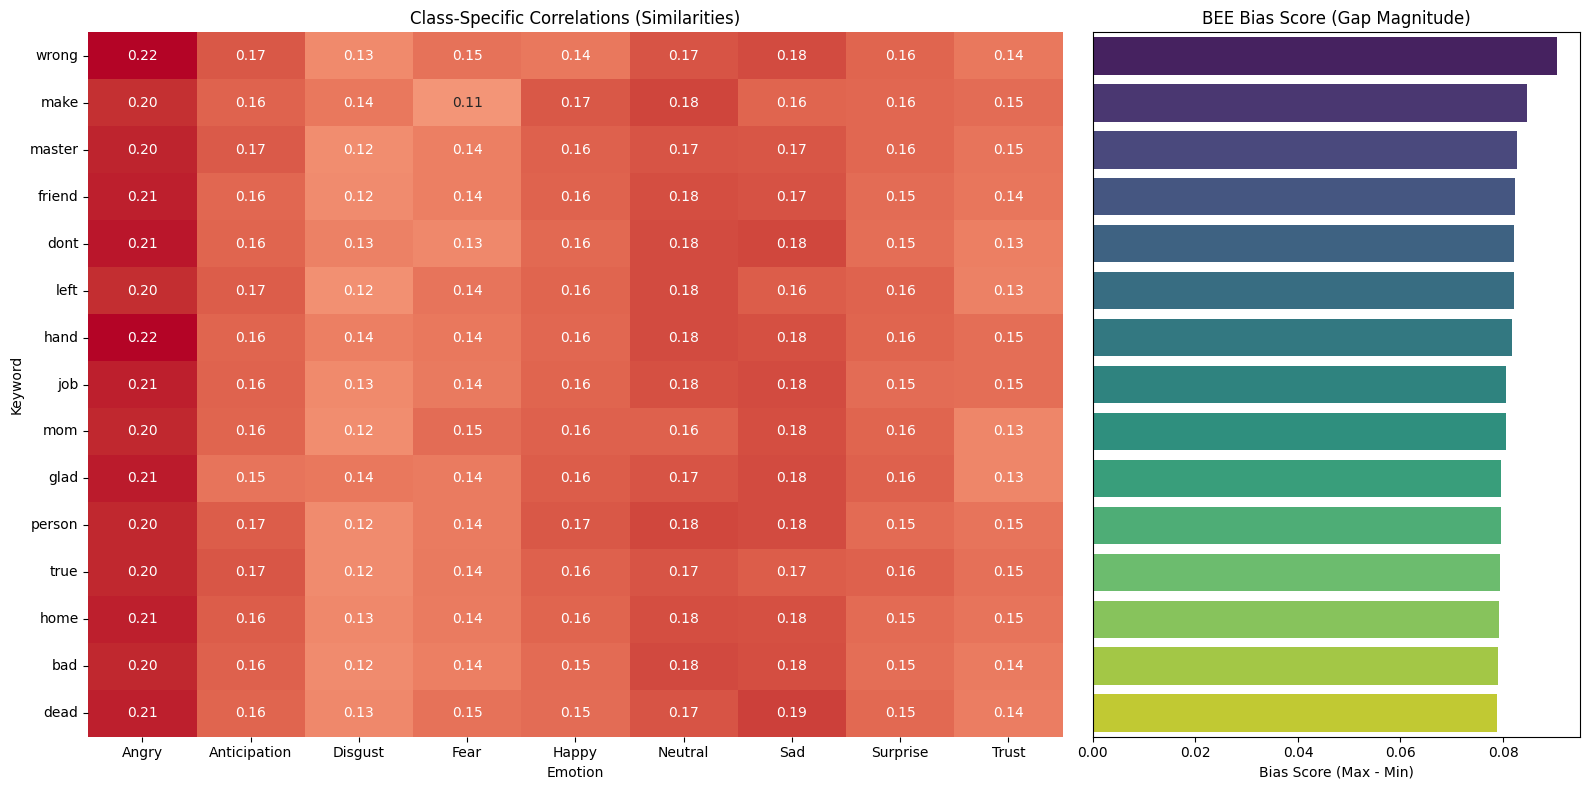

In [ ]:
# Visualize Bias Score vs Class Similarities
import matplotlib.pyplot as plt
import seaborn as sns

top_k = 15
top_keywords = bee_results.sort_values('Bias_Score', ascending=False).head(top_k)

fig, axes = plt.subplots(1, 2, figsize=(16, 8), gridspec_kw={'width_ratios': [2, 1]})

heatmap_data = top_keywords.set_index('Keyword')[list(ID2LABEL.values())]
sns.heatmap(
    heatmap_data,
    cmap="coolwarm",
    center=0,
    annot=True,
    fmt=".2f",
    cbar=False,
    ax=axes[0]
)
axes[0].set_title("Class-Specific Correlations (Similarities)")
axes[0].set_xlabel("Emotion")
axes[0].set_ylabel("Keyword")

sns.barplot(
    data=top_keywords,
    y='Keyword',
    x='Bias_Score',
    hue='Keyword',
    palette="viridis",
    ax=axes[1],
    legend=False
)
axes[1].set_title("BEE Bias Score (Gap Magnitude)")
axes[1].set_xlabel("Bias Score (Max - Min)")
axes[1].set_ylabel("")
axes[1].set_yticks([])

# Adjust layout
plt.tight_layout()
plt.show()

In [47]:
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
pd.set_option('display.max_colwidth', None)
print(bee_results)

       Keyword  Bias_Score     Angry  Anticipation   Disgust      Fear  \
0        wrong    0.090489  0.216344      0.168579  0.125856  0.146969   
1         make    0.084739  0.198054      0.160203  0.140957  0.113315   
2       master    0.082814  0.204072      0.167252  0.121258  0.135820   
3       friend    0.082317  0.205570      0.156352  0.123253  0.135968   
4         dont    0.082186  0.208872      0.158575  0.132798  0.126686   
5         left    0.082070  0.199445      0.165247  0.117375  0.144756   
6         hand    0.081771  0.217145      0.157976  0.135374  0.141663   
7          job    0.080573  0.205725      0.160769  0.125152  0.140807   
8          mom    0.080538  0.202593      0.158132  0.122055  0.152076   
9         glad    0.079564  0.207279      0.145016  0.141768  0.138289   
10      person    0.079528  0.203039      0.165232  0.123511  0.139018   
11        true    0.079377  0.201760      0.170066  0.122383  0.140162   
12        home    0.079263  0.205170  

In [ ]:
# Show Top Keywords per Emotion
for label in LABEL_NAMES:
    print(f"\n=== Top Keywords for: {label} ===")

    top_for_label = bee_results.sort_values(by=label, ascending=False) 

    print(top_for_label[['Keyword', label]].to_string(index=False))


=== Top Keywords for: Angry ===
  Keyword    Angry
     hand 0.217145
    wrong 0.216344
      ugh 0.212807
      put 0.211966
      n’t 0.211863
     yeah 0.209569
    smile 0.209134
    cried 0.209053
     dont 0.208872
  finally 0.208723
   spirit 0.208606
   stupid 0.208565
    power 0.208270
     dear 0.207827
    sound 0.207807
    state 0.207676
    party 0.207591
     glad 0.207279
    funny 0.206740
     show 0.206503
  feeling 0.206477
     feel 0.206367
     soul 0.206337
  totally 0.206304
      air 0.206096
     dead 0.205967
     hate 0.205796
      job 0.205725
     stop 0.205679
  persons 0.205583
   friend 0.205570
     game 0.205502
     home 0.205170
 honestly 0.205047
     felt 0.204930
   French 0.204873
     find 0.204745
   reason 0.204632
    sense 0.204618
     call 0.204587
   things 0.204579
     wait 0.204511
 suddenly 0.204473
      bit 0.204362
     haha 0.204198
     holy 0.204137
   master 0.204072
      fun 0.204037
  English 0.203867
     nice 0.20385

Now the finetuned model (target model)

In [49]:
import zipfile
import os

target_zip = "Target_Victim_Model.zip"
target_folder = "./restored_target_model"

def unzip_model(zip_path, extract_to):
    if not os.path.exists(zip_path):
        return False
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(extract_to)
    return True

if not unzip_model(target_zip, target_folder):
    raise FileNotFoundError("Target model zip not found.")

!pip install -q yake nltk

In [50]:
import torch
import pandas as pd
import numpy as np
import yake
import nltk
from tqdm import tqdm
from nltk.corpus import stopwords
from transformers import AutoModelForSequenceClassification, AutoTokenizer
from torch.utils.data import DataLoader
from datasets import Dataset
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
import seaborn as sns

nltk.download('stopwords')
nltk.download('punkt')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [51]:
tokenizer = AutoTokenizer.from_pretrained(target_folder)
model = AutoModelForSequenceClassification.from_pretrained(target_folder)
model.to("cuda")
model.eval()

Loading weights:   0%|          | 0/76 [00:00<?, ?it/s]

GPTNeoXForSequenceClassification(
  (gpt_neox): GPTNeoXModel(
    (embed_in): Embedding(50304, 128)
    (emb_dropout): Dropout(p=0.0, inplace=False)
    (layers): ModuleList(
      (0-5): 6 x GPTNeoXLayer(
        (input_layernorm): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
        (post_attention_layernorm): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
        (post_attention_dropout): Dropout(p=0.0, inplace=False)
        (post_mlp_dropout): Dropout(p=0.0, inplace=False)
        (attention): GPTNeoXAttention(
          (query_key_value): Linear(in_features=128, out_features=384, bias=True)
          (dense): Linear(in_features=128, out_features=128, bias=True)
        )
        (mlp): GPTNeoXMLP(
          (dense_h_to_4h): Linear(in_features=128, out_features=512, bias=True)
          (dense_4h_to_h): Linear(in_features=512, out_features=128, bias=True)
          (act): GELUActivation()
        )
      )
    )
    (final_layer_norm): LayerNorm((128,), eps=1e-05, 

In [ ]:
ID2LABEL = {
    0: "Angry", 1: "Anticipation", 2: "Disgust", 3: "Fear",
    4: "Happy", 5: "Neutral", 6: "Sad", 7: "Surprise", 8: "Trust"
}
LABEL_NAMES = list(ID2LABEL.values())

def normalize_embeddings(embeddings):
    return embeddings / np.maximum(np.linalg.norm(embeddings, axis=1, keepdims=True), 1e-8)

def extract_keywords_from_text(texts, top=50):
    text_combined = " ".join([str(t) for t in texts])

    kw_extractor = yake.KeywordExtractor(
        lan="en",
        n=1,
        dedupLim=0.9,
        top=top,
        features=None
    )
    keywords = kw_extractor.extract_keywords(text_combined)
    return [k[0] for k in keywords]

In [53]:
if not os.path.exists("/content/drive/MyDrive/all_4_datasets.csv"):
    raise FileNotFoundError("all_4_datasets.csv not found.")

df = pd.read_csv("/content/drive/MyDrive/all_4_datasets.csv")
df = df.dropna(subset=['text', 'label'])
df['text'] = df['text'].astype(str)

le = LabelEncoder()
df['label_id'] = le.fit_transform(df['label'])

dataset = Dataset.from_pandas(df[['text', 'label_id']].rename(columns={'label_id': 'labels'}))
dataset = dataset.train_test_split(test_size=0.1)

def tokenize_function(examples):
    return tokenizer(examples["text"], padding="max_length", truncation=True, max_length=128)

tokenized_datasets = dataset.map(tokenize_function, batched=True)
tokenized_datasets.set_format(type='torch', columns=['input_ids', 'attention_mask', 'labels'])

Map:   0%|          | 0/384561 [00:00<?, ? examples/s]

Map:   0%|          | 0/42729 [00:00<?, ? examples/s]

In [54]:
def get_embeddings(model, tokenizer, dataset, batch_size=32):
    dataloader = DataLoader(dataset, batch_size=batch_size)
    embeddings = []
    labels = []

    with torch.no_grad():
        for batch in tqdm(dataloader):
            input_ids = batch['input_ids'].to("cuda")
            attention_mask = batch['attention_mask'].to("cuda")
            batch_labels = batch['labels'].numpy()

            outputs = model(input_ids=input_ids, attention_mask=attention_mask, output_hidden_states=True)
            last_hidden_state = outputs.hidden_states[-1]

            seq_lengths = attention_mask.sum(dim=1) - 1
            batch_indices = torch.arange(last_hidden_state.size(0)).to("cuda")
            batch_embeddings = last_hidden_state[batch_indices, seq_lengths]

            embeddings.append(batch_embeddings.cpu().numpy())
            labels.append(batch_labels)

    return np.concatenate(embeddings), np.concatenate(labels)

train_embeddings, train_labels = get_embeddings(model, tokenizer, tokenized_datasets["train"])
train_embeddings_norm = normalize_embeddings(train_embeddings)

100%|██████████| 12018/12018 [01:42<00:00, 117.52it/s]


In [55]:
classifier_weights = model.score.weight.detach().cpu().numpy()
classifier_weights_norm = normalize_embeddings(classifier_weights)

In [ ]:
import torch
import numpy as np
from transformers import AutoTokenizer

# 1. Identify and Reload the Tokenizer from the source
model_name = model.config._name_or_path
print(f"Reloading fresh tokenizer for: {model_name}")

tokenizer = AutoTokenizer.from_pretrained(model_name, use_fast=False)

# 2. Hard-reset the configuration
tokenizer.pad_token = tokenizer.eos_token
tokenizer.padding_side = "left"
tokenizer.model_max_length = 2048

# 3. VERIFICATION TEST
test_ids = tokenizer.encode("feel")
print(f"Verification - Tokens for 'feel': {test_ids}")

if not test_ids:
    # If it still fails, we force a generic GPT-NeoX tokenizer as a last resort
    print("Standard load failed. Forcing Pythia-14m tokenizer as fallback...")
    tokenizer = AutoTokenizer.from_pretrained("EleutherAI/pythia-14m")
    tokenizer.pad_token = tokenizer.eos_token
    test_ids = tokenizer.encode("feel")
    print(f"Fallback Verification - Tokens for 'feel': {test_ids}")

all_texts = df['text'].tolist()
raw_keywords = extract_keywords_from_text(all_texts, top=200)

filter_words = set([w.lower() for w in LABEL_NAMES])
clean_keywords = [str(k).strip() for k in raw_keywords if str(k).lower() not in filter_words and len(str(k).strip()) > 0]

def embed_text_list(text_list, model, tokenizer, batch_size=64):
    model.eval()
    all_embeddings = []
    for i in range(0, len(text_list), batch_size):
        batch_texts = text_list[i : i + batch_size]
        inputs = tokenizer(batch_texts, padding=True, truncation=True, return_tensors="pt").to("cuda")

        if inputs.input_ids.shape[1] == 0:
            continue

        with torch.no_grad():
            outputs = model(**inputs, output_hidden_states=True)
            last_hidden = outputs.hidden_states[-1]
            mask = inputs.attention_mask
            seq_lens = (mask.sum(dim=1) - 1).clamp(min=0)
            embeddings = last_hidden[torch.arange(last_hidden.size(0)), seq_lens]
            all_embeddings.append(embeddings.cpu().numpy())

    return np.vstack(all_embeddings)

keyword_embeddings = embed_text_list(clean_keywords, model, tokenizer, batch_size=64)
keyword_embeddings_norm = normalize_embeddings(keyword_embeddings)
print(f"Success! Final shape: {keyword_embeddings_norm.shape}")

Reloading fresh tokenizer for: ./restored_target_model
Verification - Tokens for 'feel': [39336]
Success! Final shape: (197, 128)


In [57]:
similarities = classifier_weights_norm @ keyword_embeddings_norm.T
max_sim = np.max(similarities, axis=0)
min_sim = np.min(similarities, axis=0)
gap_scores = max_sim - min_sim

sorted_indices = np.argsort(gap_scores)[::-1]
sorted_keywords = np.array(clean_keywords)[sorted_indices]
sorted_scores = gap_scores[sorted_indices]
sorted_sims = similarities[:, sorted_indices]

bee_results = pd.DataFrame({
    'Keyword': sorted_keywords,
    'Bias_Score': sorted_scores
})

for i, label in ID2LABEL.items():
    bee_results[label] = sorted_sims[i]

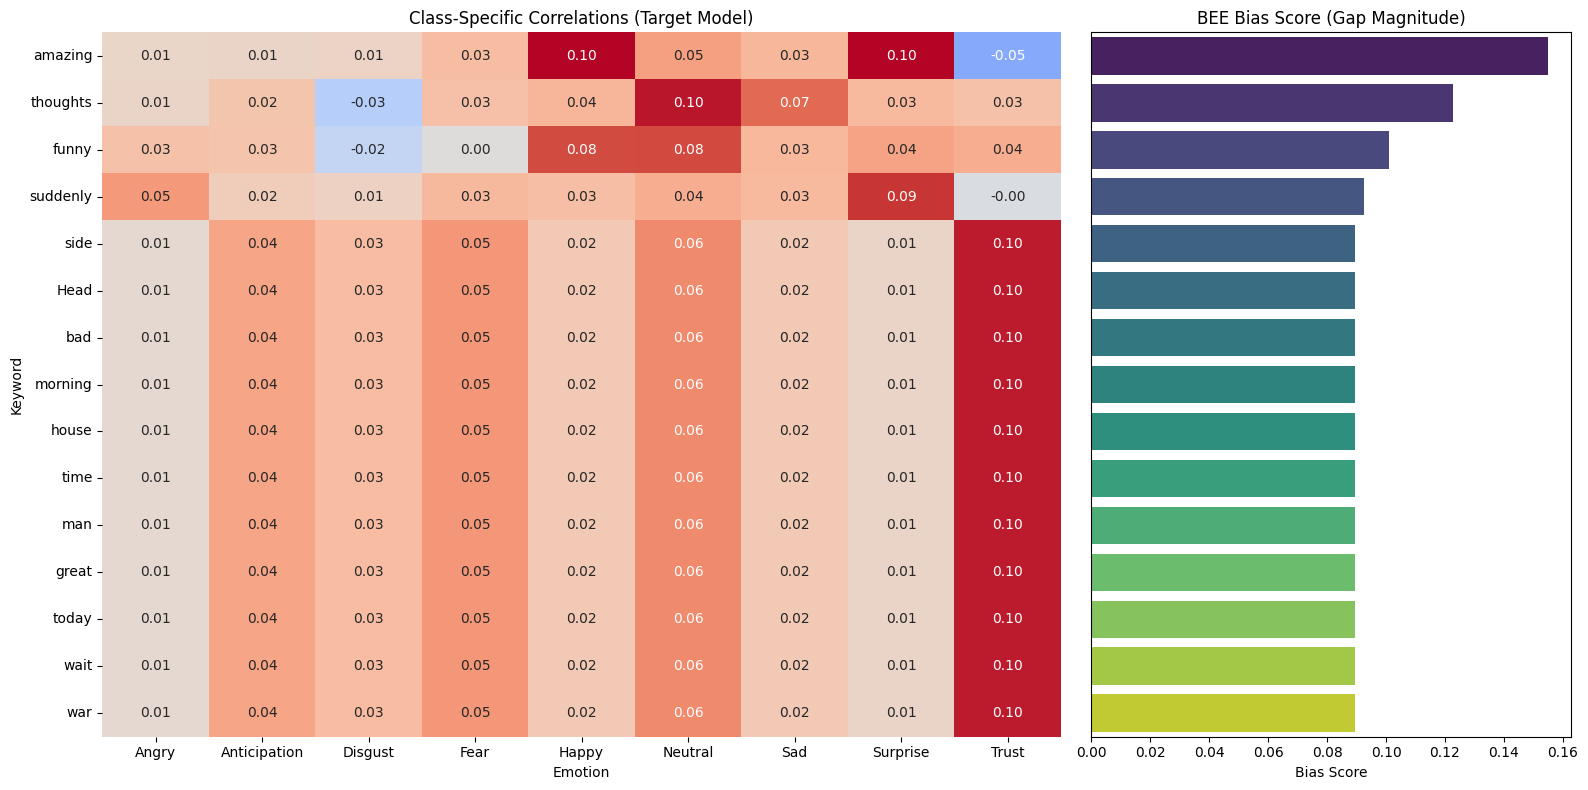

In [58]:
top_k = 15
top_keywords = bee_results.sort_values('Bias_Score', ascending=False).head(top_k)

fig, axes = plt.subplots(1, 2, figsize=(16, 8), gridspec_kw={'width_ratios': [2, 1]})

heatmap_data = top_keywords.set_index('Keyword')[list(ID2LABEL.values())]
sns.heatmap(heatmap_data, cmap="coolwarm", center=0, annot=True, fmt=".2f", cbar=False, ax=axes[0])
axes[0].set_title("Class-Specific Correlations (Target Model)")
axes[0].set_xlabel("Emotion")
axes[0].set_ylabel("Keyword")

sns.barplot(data=top_keywords, y='Keyword', x='Bias_Score', hue='Keyword', palette="viridis", ax=axes[1], legend=False)
axes[1].set_title("BEE Bias Score (Gap Magnitude)")
axes[1].set_xlabel("Bias Score")
axes[1].set_ylabel("")
axes[1].set_yticks([])

plt.tight_layout()
plt.show()

In [60]:
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
pd.set_option('display.max_colwidth', None)

for label in LABEL_NAMES:
    print(f"\n=== Top Keywords for: {label} (Target Model) ===")
    top_for_label = bee_results.sort_values(by=label, ascending=False)
    print(top_for_label[['Keyword', label]].to_string(index=False))


=== Top Keywords for: Angry (Target Model) ===
  Keyword    Angry
      sir 0.059149
   stupid 0.057878
     till 0.056832
     holy 0.056139
     haha 0.056139
     hate 0.056139
    feels 0.055469
     dear 0.053284
     dont 0.053284
  finally 0.052866
  feeling 0.051330
      n’t 0.049818
 suddenly 0.049470
  persons 0.046319
    kinda 0.045399
     knew 0.043685
yesterday 0.042756
     soul 0.042131
   sister 0.042131
     glad 0.041252
  totally 0.041046
    smile 0.040849
 honestly 0.035601
    loved 0.034815
     gods 0.034277
    cried 0.032916
     Mrs. 0.031899
     Thou 0.031075
   hearts 0.031024
     yeah 0.030853
      wow 0.030185
     hear 0.028868
    Loves 0.028605
 feelings 0.028332
 tomorrow 0.027418
    funny 0.027412
  tonight 0.027289
     thee 0.027187
     gave 0.024607
   looked 0.023838
  Mothers 0.019223
beautiful 0.018408
     eyes 0.018110
   Heaven 0.016232
 thoughts 0.011815
  amazing 0.010780
      lol 0.010375
     fine 0.006701
   reason 0.006701
  